In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from collections import Counter
pd.set_option('display.precision', 3)
from pandas import read_csv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn import preprocessing
from pandas.plotting import scatter_matrix
from scipy.stats import boxcox
from statsmodels.genmod.generalized_linear_model import GLM
from sklearn.model_selection import train_test_split

In [24]:
import os

# 1. Mira dónde estás ahora
print(f"Directorio actual: {os.getcwd()}")

# 2. Cambia a la carpeta raíz del proyecto
# Asegúrate de que esta ruta coincida con tu carpeta principal
ruta_raiz = r'C:\Users\dijor\Q4\AA1\ML-WiFi-Sensing-Classification'
os.chdir(ruta_raiz)

print(f"Nuevo directorio de trabajo: {os.getcwd()}")

Directorio actual: C:\Users\dijor\Q4\AA1\ML-WiFi-Sensing-Classification
Nuevo directorio de trabajo: C:\Users\dijor\Q4\AA1\ML-WiFi-Sensing-Classification


In [25]:
wifi = pd.read_csv('data/processed/dataset_final_preprocessed.csv', header=0, delimiter=',')
X_test_nolabels = pd.read_csv('data/processed/test_final_preprocessed.csv', header=0, delimiter=',')
wifi.shape

(11599, 280)

In [26]:
wifi.head()

,aoa,rssi1,rssi2,mag1_1,mag2_1,mag3_1,mag4_1,mag5_1,mag6_1,mag7_1,...,circular_mean_r_1,mean_mag_2,std_mag_2,max_mag_2,mean_cos_2,mean_sin_2,weighted_phase_mean_2,weighted_phase_std_2,circular_mean_r_2,position
0,-1.533,-0.8,-0.643,-2.406,-1.289,-2.414,-2.438,-1.780,-1.794,-1.234,...,-16.002,-0.826,0.925,1.248,0.116,-0.633,-0.500,0.563,-1.218,9
1,0.497,-1.1,-0.643,-1.149,-2.152,-0.758,-1.285,-1.515,-1.111,-1.488,...,-3.161,-2.298,1.083,0.524,-0.498,-0.050,0.208,5.635,-2.703,9
2,0.004,-0.6,-0.571,0.029,-2.308,0.104,0.239,1.403,0.957,-0.681,...,-0.644,-0.511,0.134,0.163,0.395,0.571,0.372,0.677,-1.682,9
3,0.342,-0.1,0.571,-0.784,-1.170,-1.657,-1.748,-1.864,-1.536,-2.271,...,-4.341,0.764,0.720,0.605,-0.372,0.770,0.763,-0.036,-0.010,2
4,0.245,-0.2,0.214,-1.596,-1.617,-1.051,-2.940,-1.287,-2.203,-2.429,...,-2.243,-0.627,-0.565,-0.556,0.662,0.364,0.190,-0.063,0.021,2


In [27]:
wifi.describe()

,aoa,rssi1,rssi2,mag1_1,mag2_1,mag3_1,mag4_1,mag5_1,mag6_1,mag7_1,...,circular_mean_r_1,mean_mag_2,std_mag_2,max_mag_2,mean_cos_2,mean_sin_2,weighted_phase_mean_2,weighted_phase_std_2,circular_mean_r_2,position
count,11599.000,11599.000,11599.000,11599.000,11599.000,11599.000,11599.000,11599.000,11599.000,11599.000,...,11599.000,11599.000,11599.000,11599.000,11599.000,11599.000,11599.000,11599.000,11599.000,11599.000
mean,0.011,0.237,0.121,-0.159,-0.159,-0.160,-0.107,-0.088,-0.101,-0.064,...,-0.776,-0.110,0.050,0.154,-0.012,-0.004,0.014,0.769,-0.887,4.423
std,0.851,0.688,0.588,0.865,0.849,0.846,0.931,0.928,0.913,0.930,...,2.178,0.868,0.694,0.915,0.529,0.528,0.589,1.593,2.085,2.914
min,-2.266,-1.500,-1.071,-4.248,-4.047,-4.240,-4.410,-4.187,-3.719,-3.808,...,-26.898,-6.589,-1.719,-2.872,-0.907,-0.894,-1.084,-0.304,-16.599,0.000
25%,-0.481,-0.300,-0.357,-0.609,-0.611,-0.632,-0.588,-0.602,-0.604,-0.568,...,-0.752,-0.533,-0.523,-0.431,-0.514,-0.506,-0.487,-0.167,-0.876,2.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,4.000
75%,0.519,0.700,0.643,0.391,0.389,0.368,0.412,0.398,0.396,0.432,...,0.248,0.467,0.477,0.569,0.486,0.494,0.513,0.833,0.124,7.000
max,2.299,2.200,1.500,3.397,3.226,3.607,6.195,3.157,3.737,3.581,...,0.465,2.265,3.329,8.116,0.900,0.888,1.137,6.525,0.195,9.000


array([<Axes: title={'center': 'aoa'}>], dtype=object)

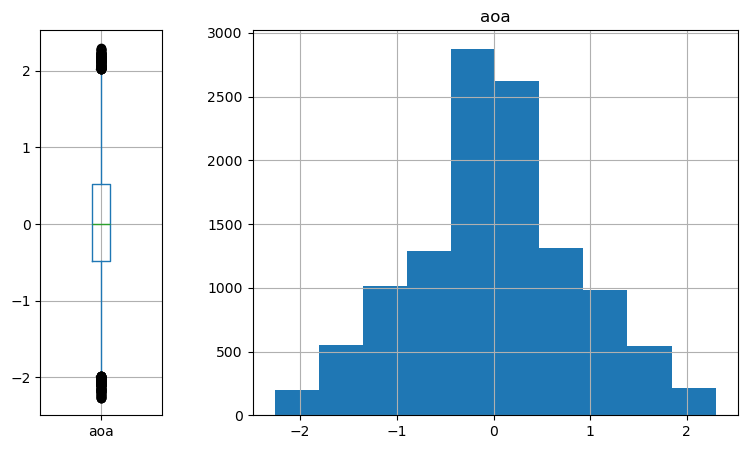

In [28]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
wifi.boxplot(column='aoa',ax=axes[0])
wifi.hist(column='aoa', ax=axes[1])

array([<Axes: title={'center': 'rssi1'}>], dtype=object)

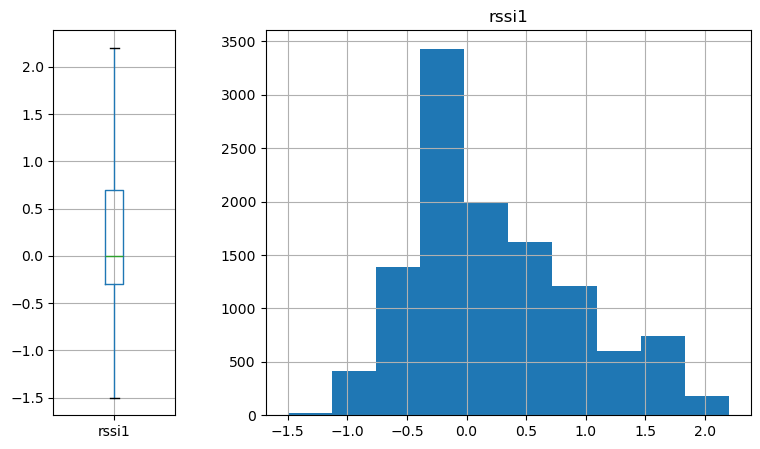

In [29]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
wifi.boxplot(column='rssi1',ax=axes[0])
wifi.hist(column='rssi1', ax=axes[1])

array([<Axes: title={'center': 'rssi2'}>], dtype=object)

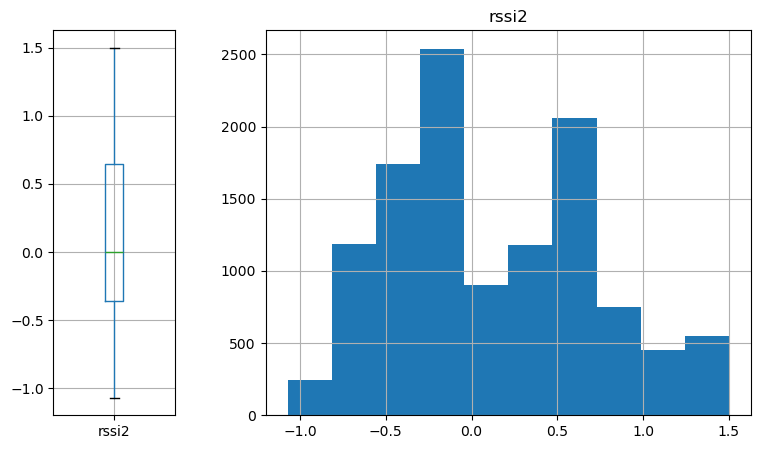

In [30]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
wifi.boxplot(column='rssi2',ax=axes[0])
wifi.hist(column='rssi2', ax=axes[1])

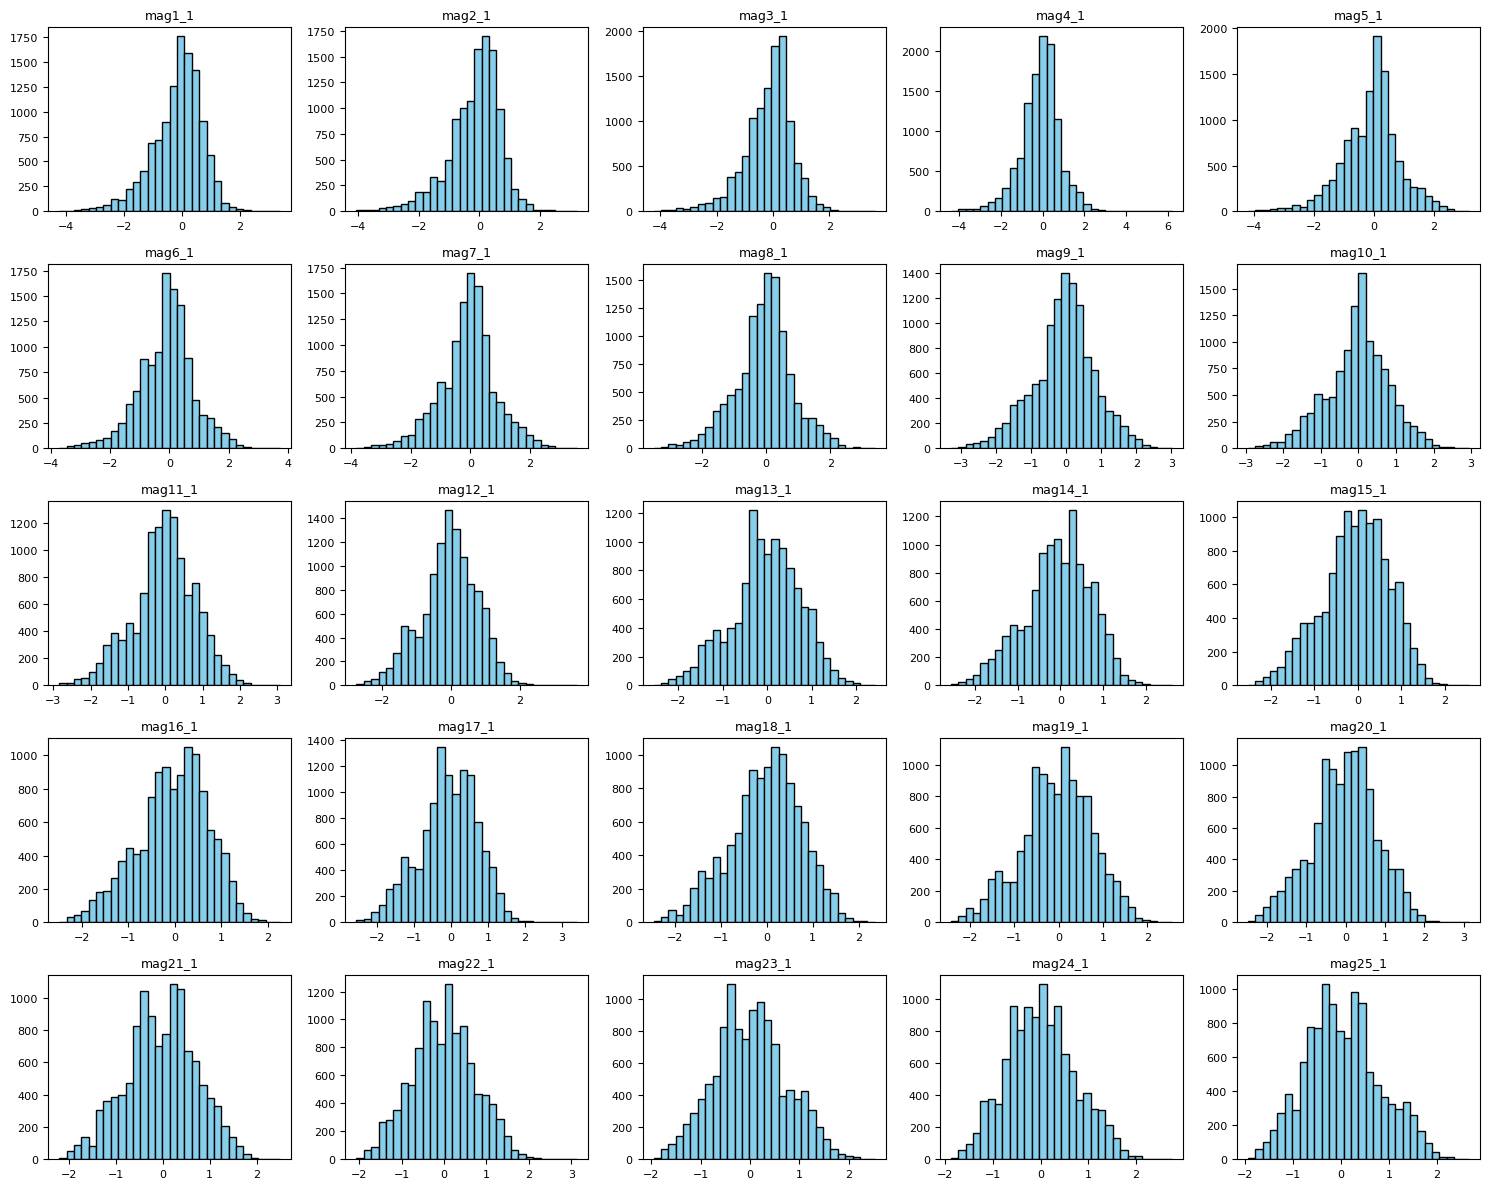

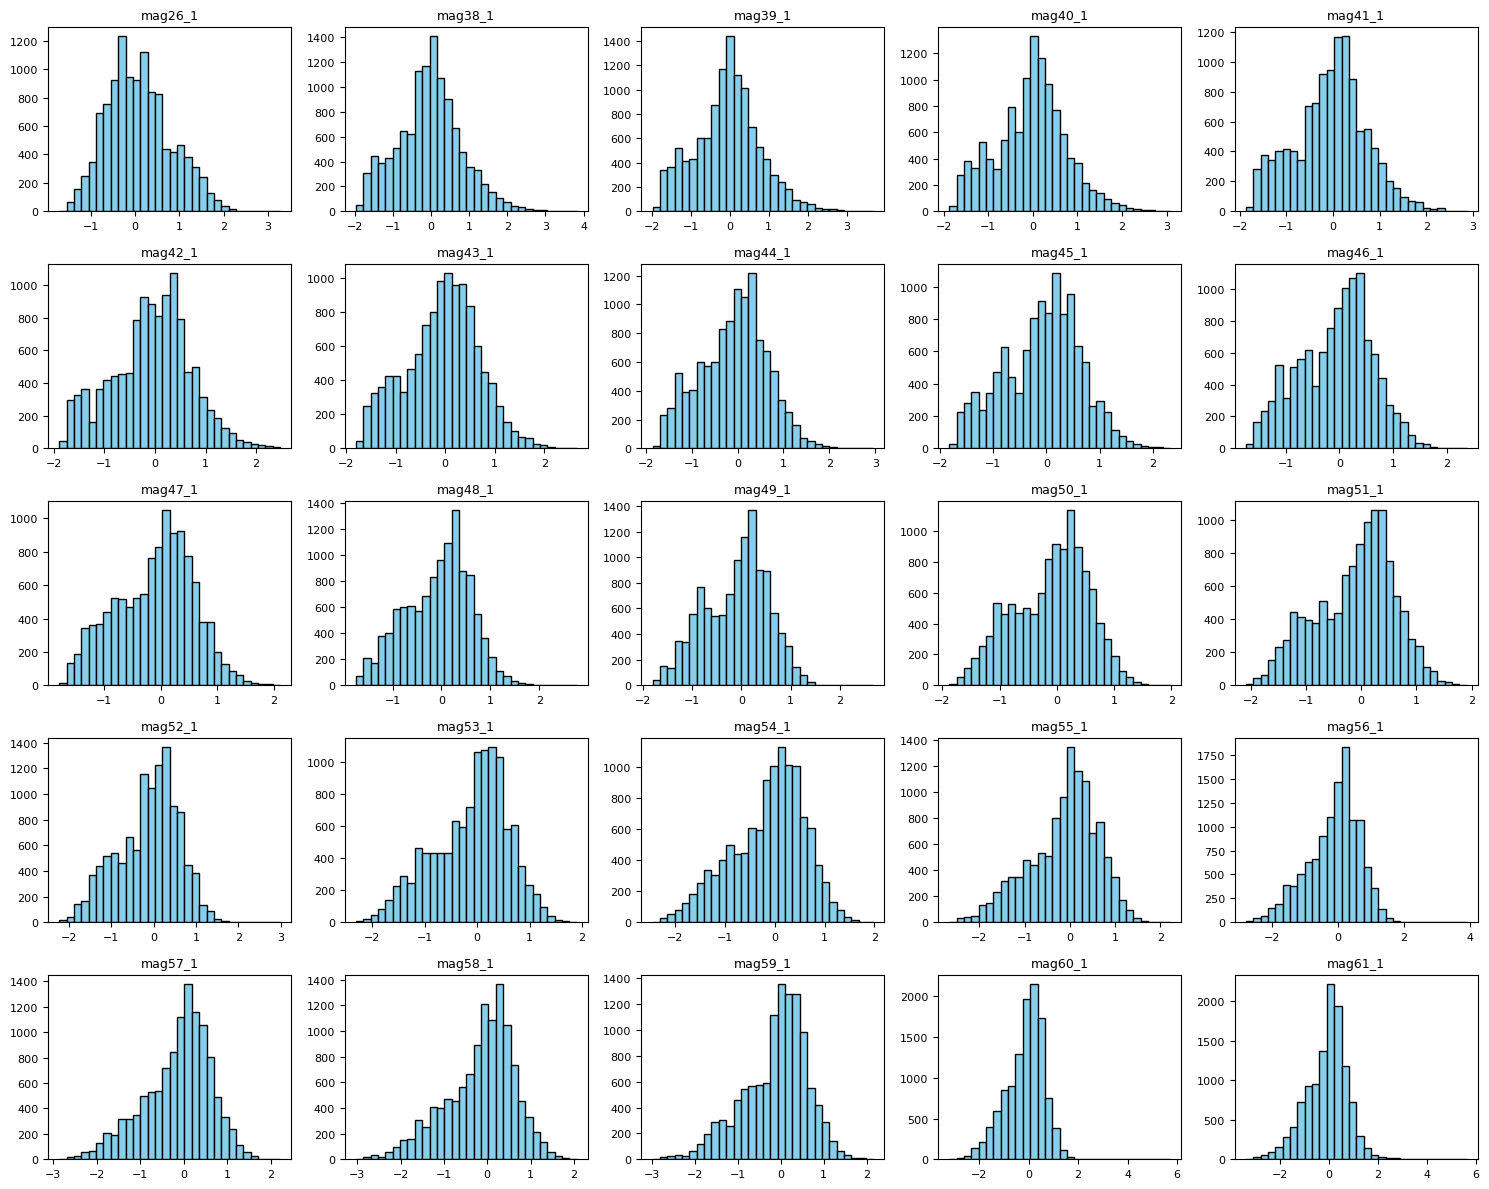

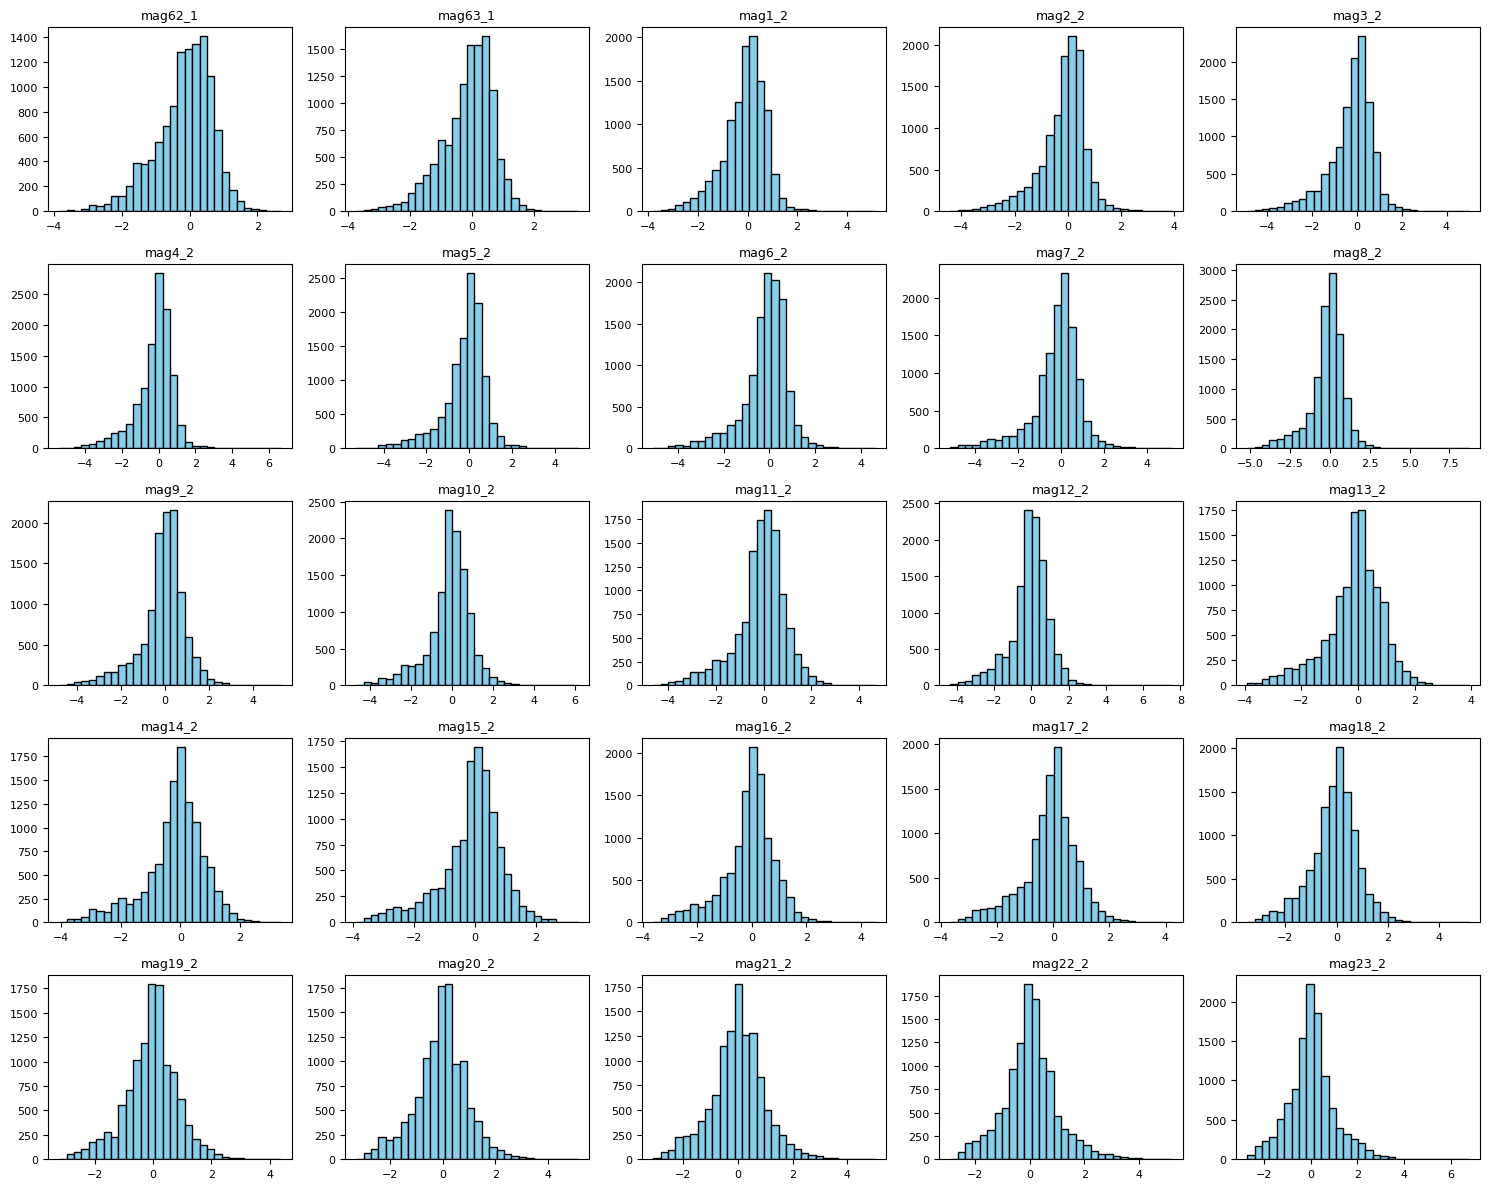

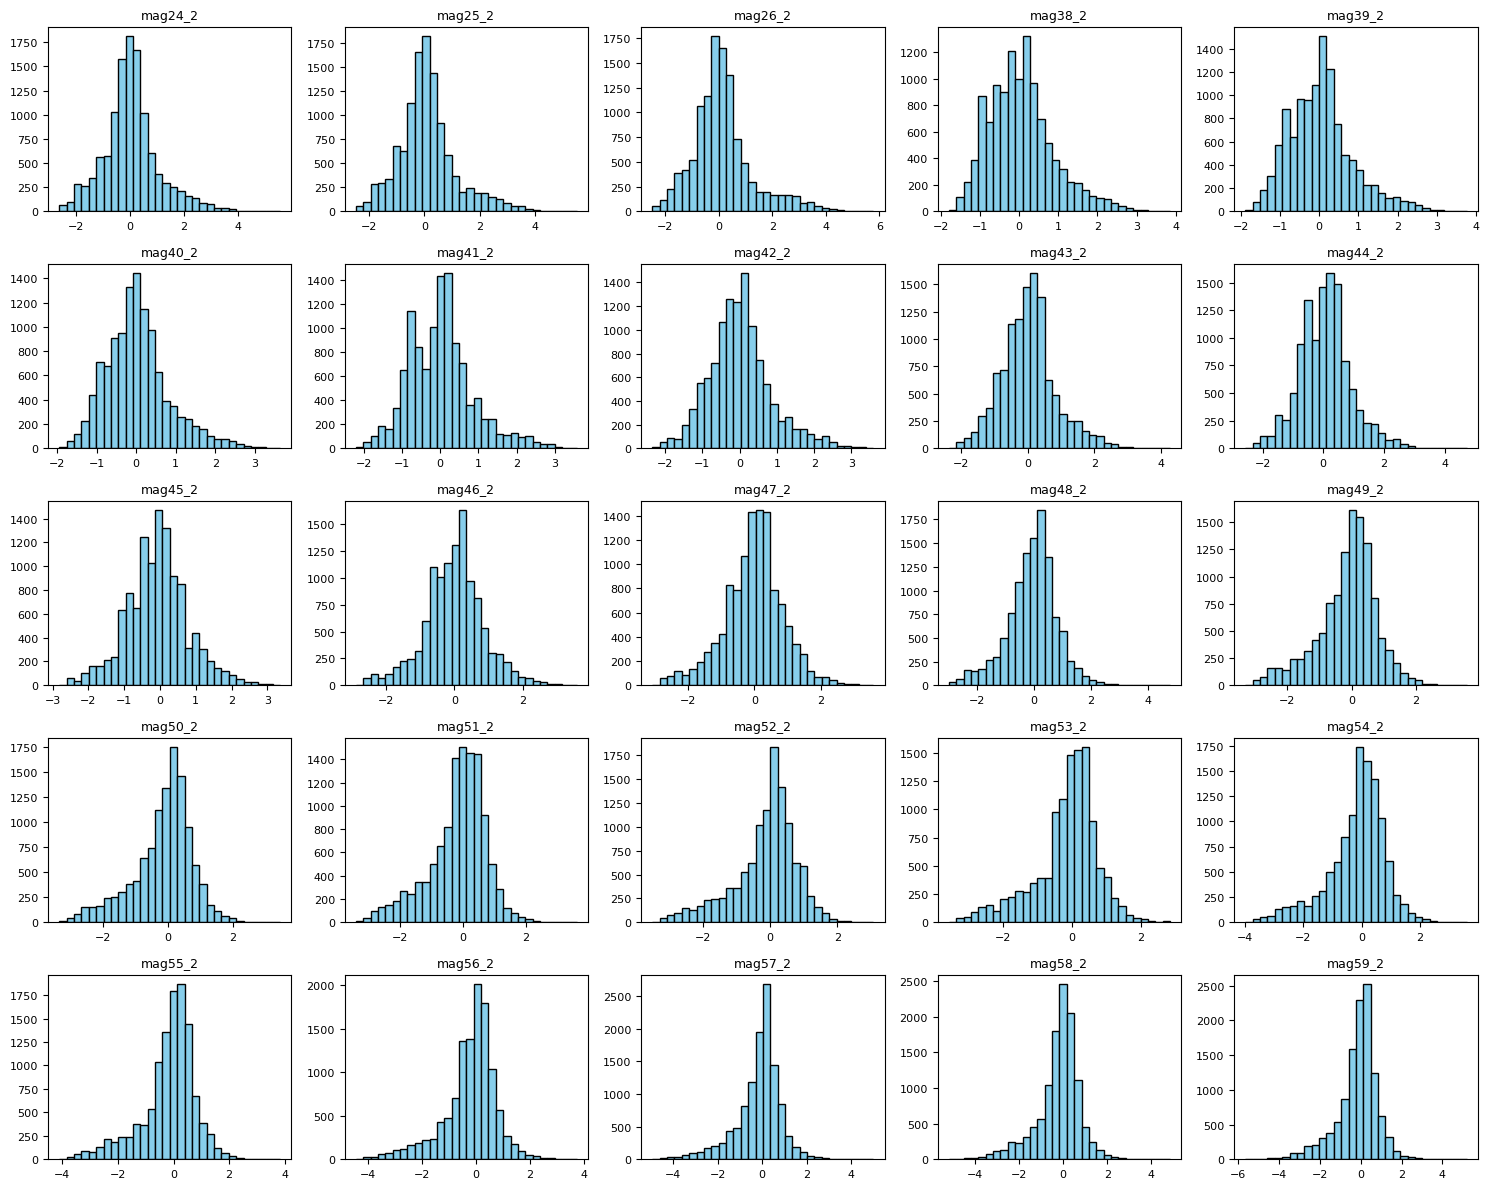

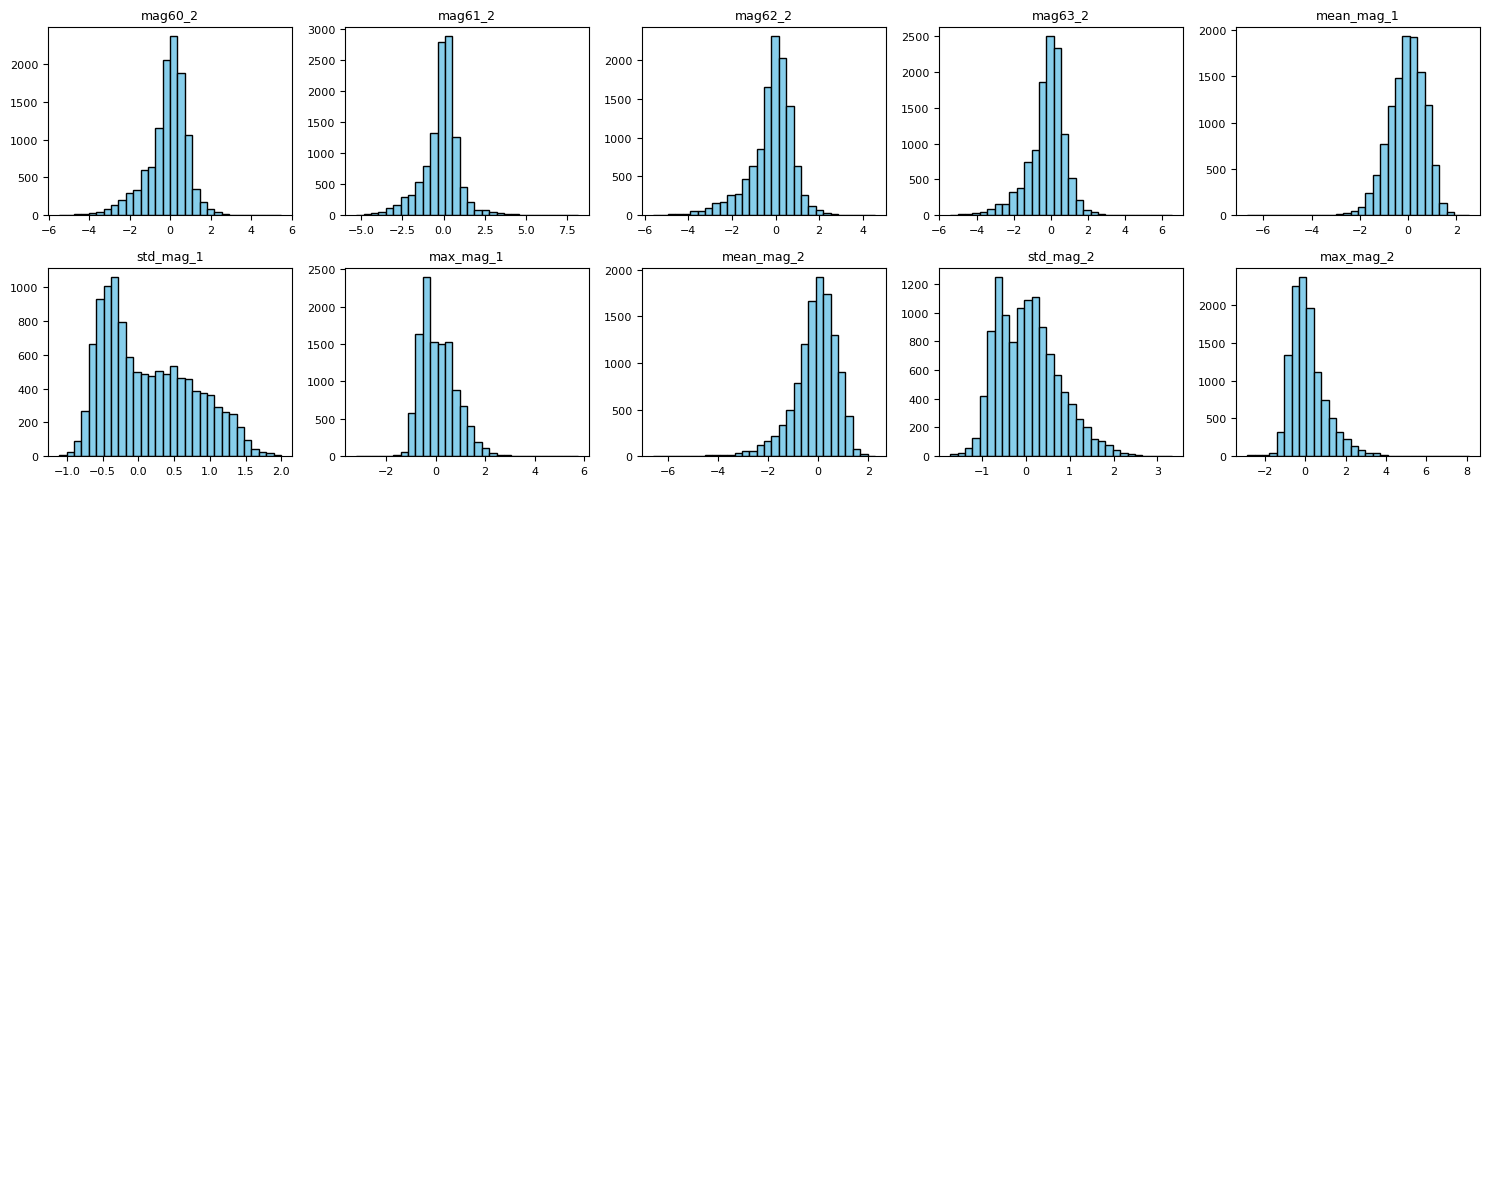

In [31]:
import matplotlib.pyplot as plt
import math

# 1. Identificar todas las columnas de magnitud (asumiendo que las llamaste 'amp...')
cols_mag = [col for col in wifi.columns if 'mag' in col]

# 2. Configuración de la cuadrícula
n_cols_grid = 5
n_rows_grid = 5
fotos_por_pagina = n_cols_grid * n_rows_grid

# 3. Bucle para mostrar de 25 en 25
for i in range(0, len(cols_mag), fotos_por_pagina):
    # Seleccionamos el bloque de 25 columnas
    bloque = cols_mag[i : i + fotos_por_pagina]
    
    # Creamos la figura
    fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(15, 12))
    axes = axes.flatten() # Aplanar para iterar fácilmente
    
    for j, col in enumerate(bloque):
        # Dibujar histograma en el subgráfico correspondiente
        axes[j].hist(wifi[col], bins=30, color='skyblue', edgecolor='black')
        axes[j].set_title(col, fontsize=9)
        axes[j].tick_params(labelsize=8)
    
    # Ocultar ejes vacíos si el último bloque tiene menos de 25
    for k in range(len(bloque), fotos_por_pagina):
        axes[k].axis('off')
    
    plt.tight_layout()
    plt.show()

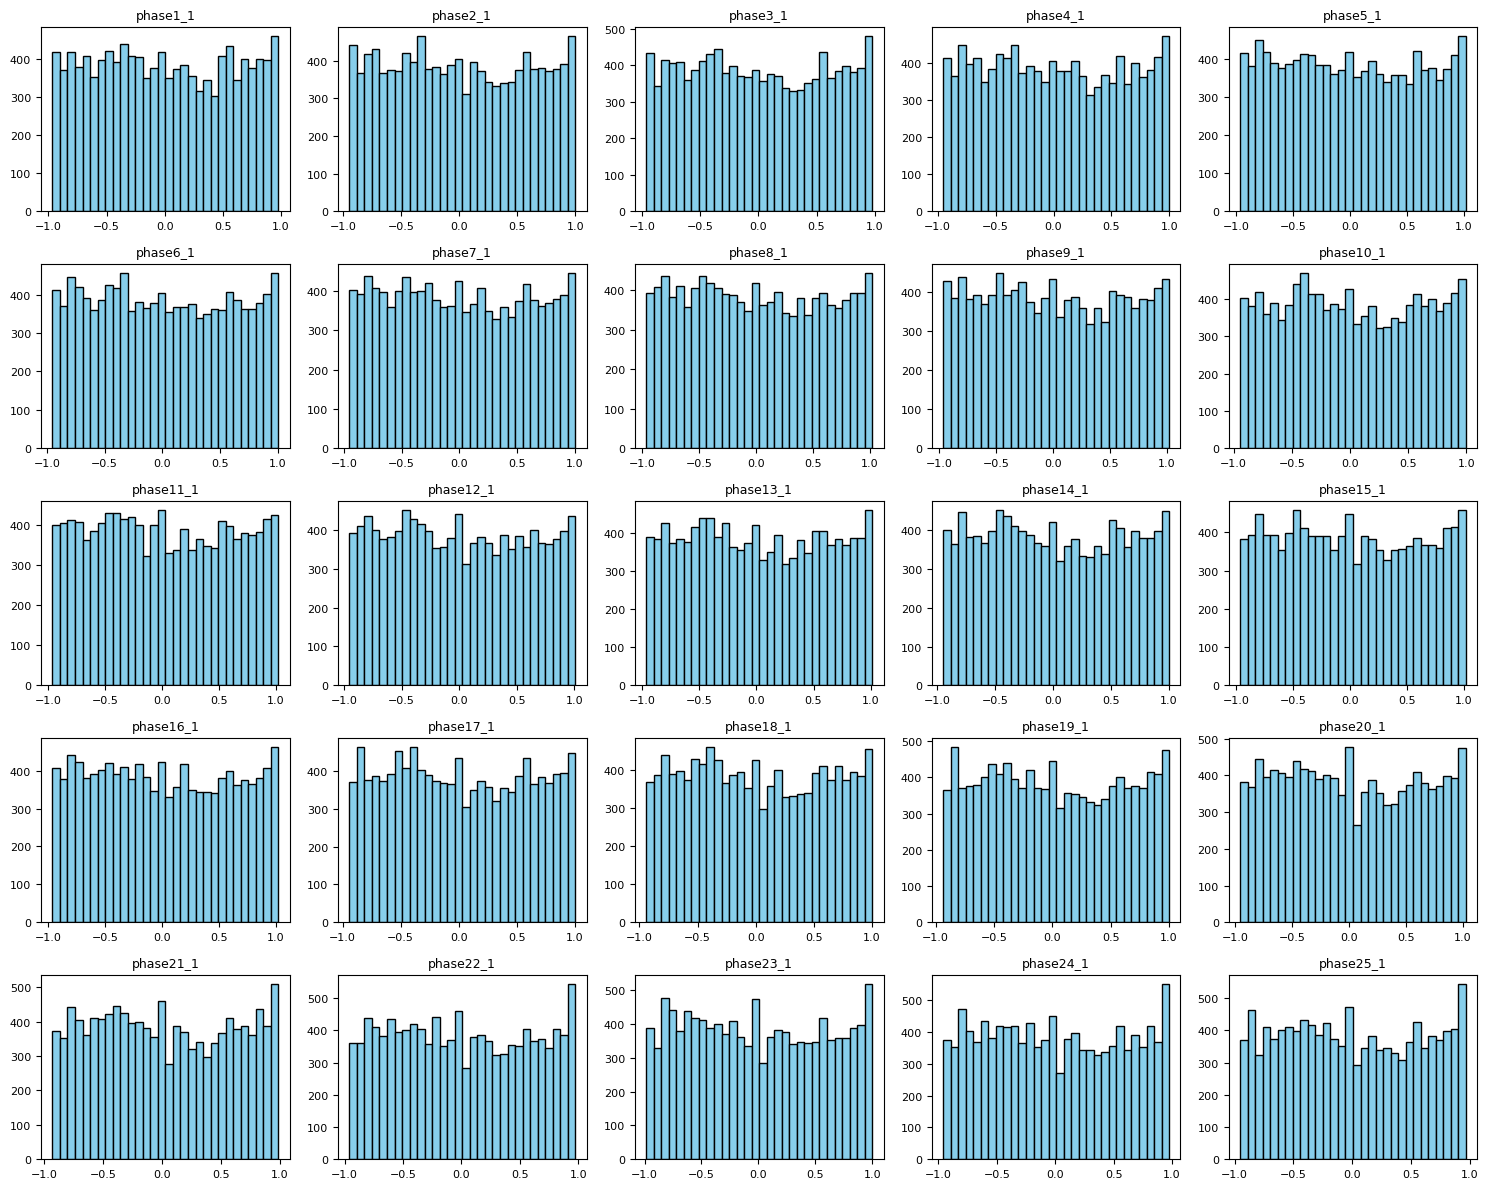

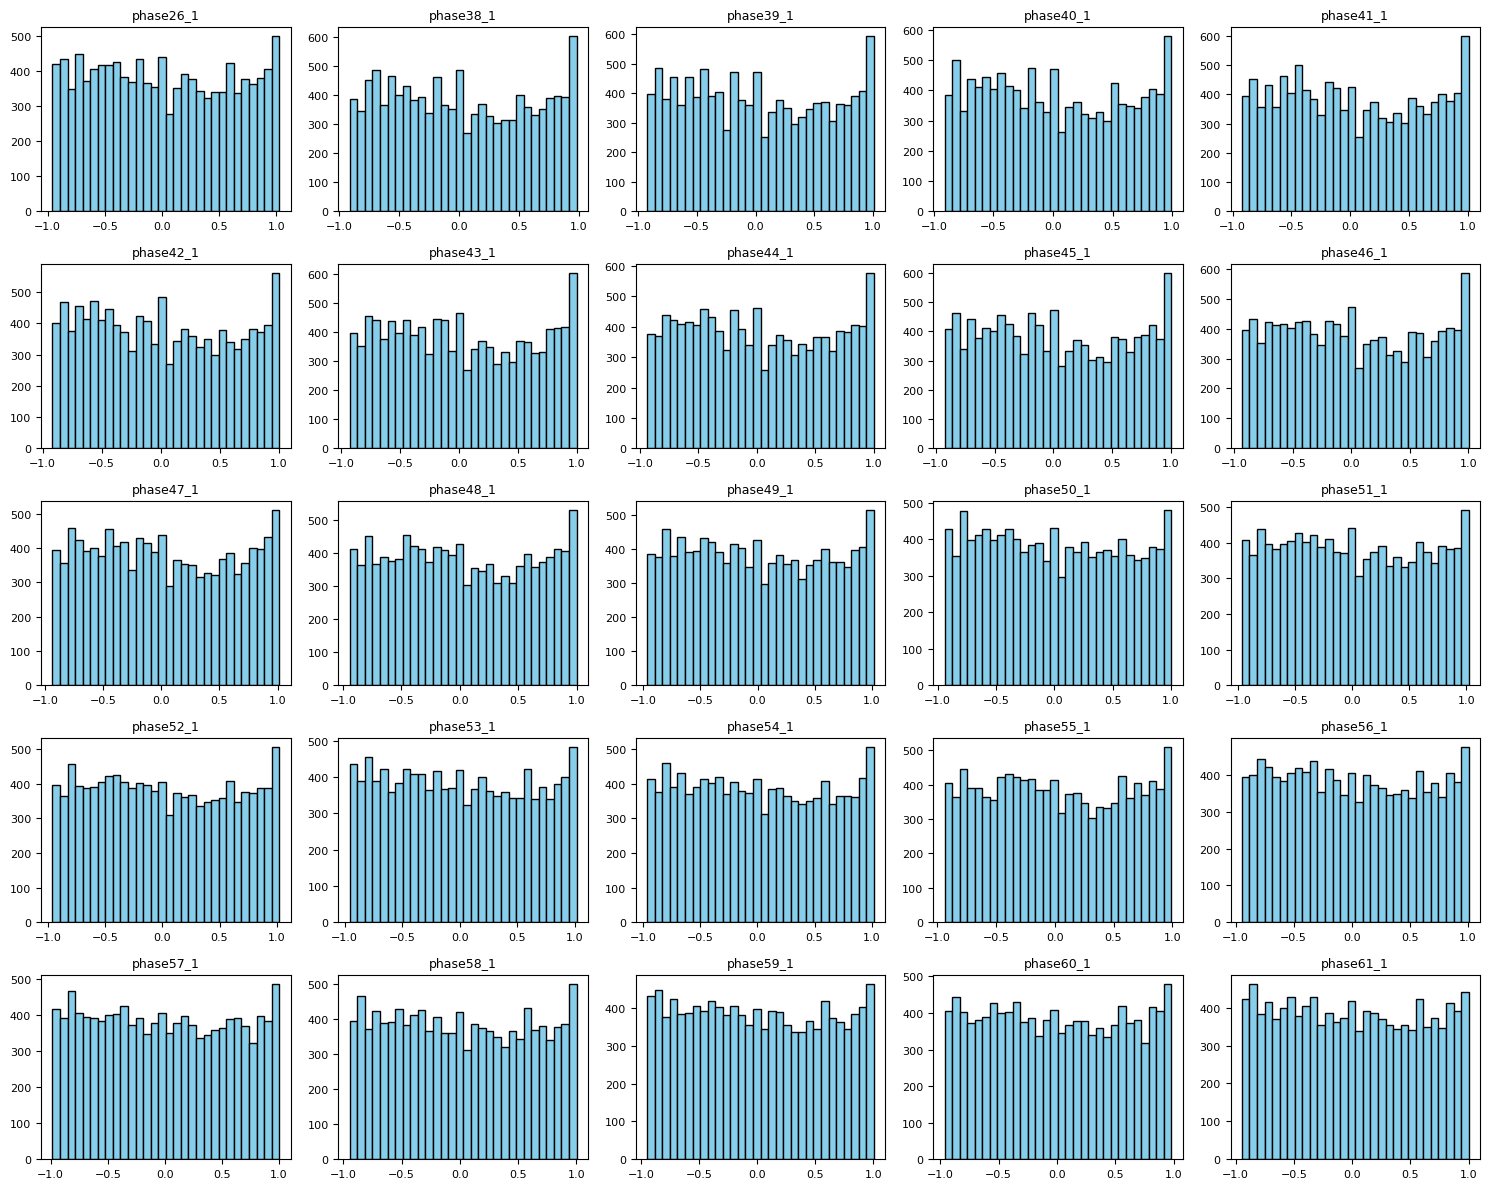

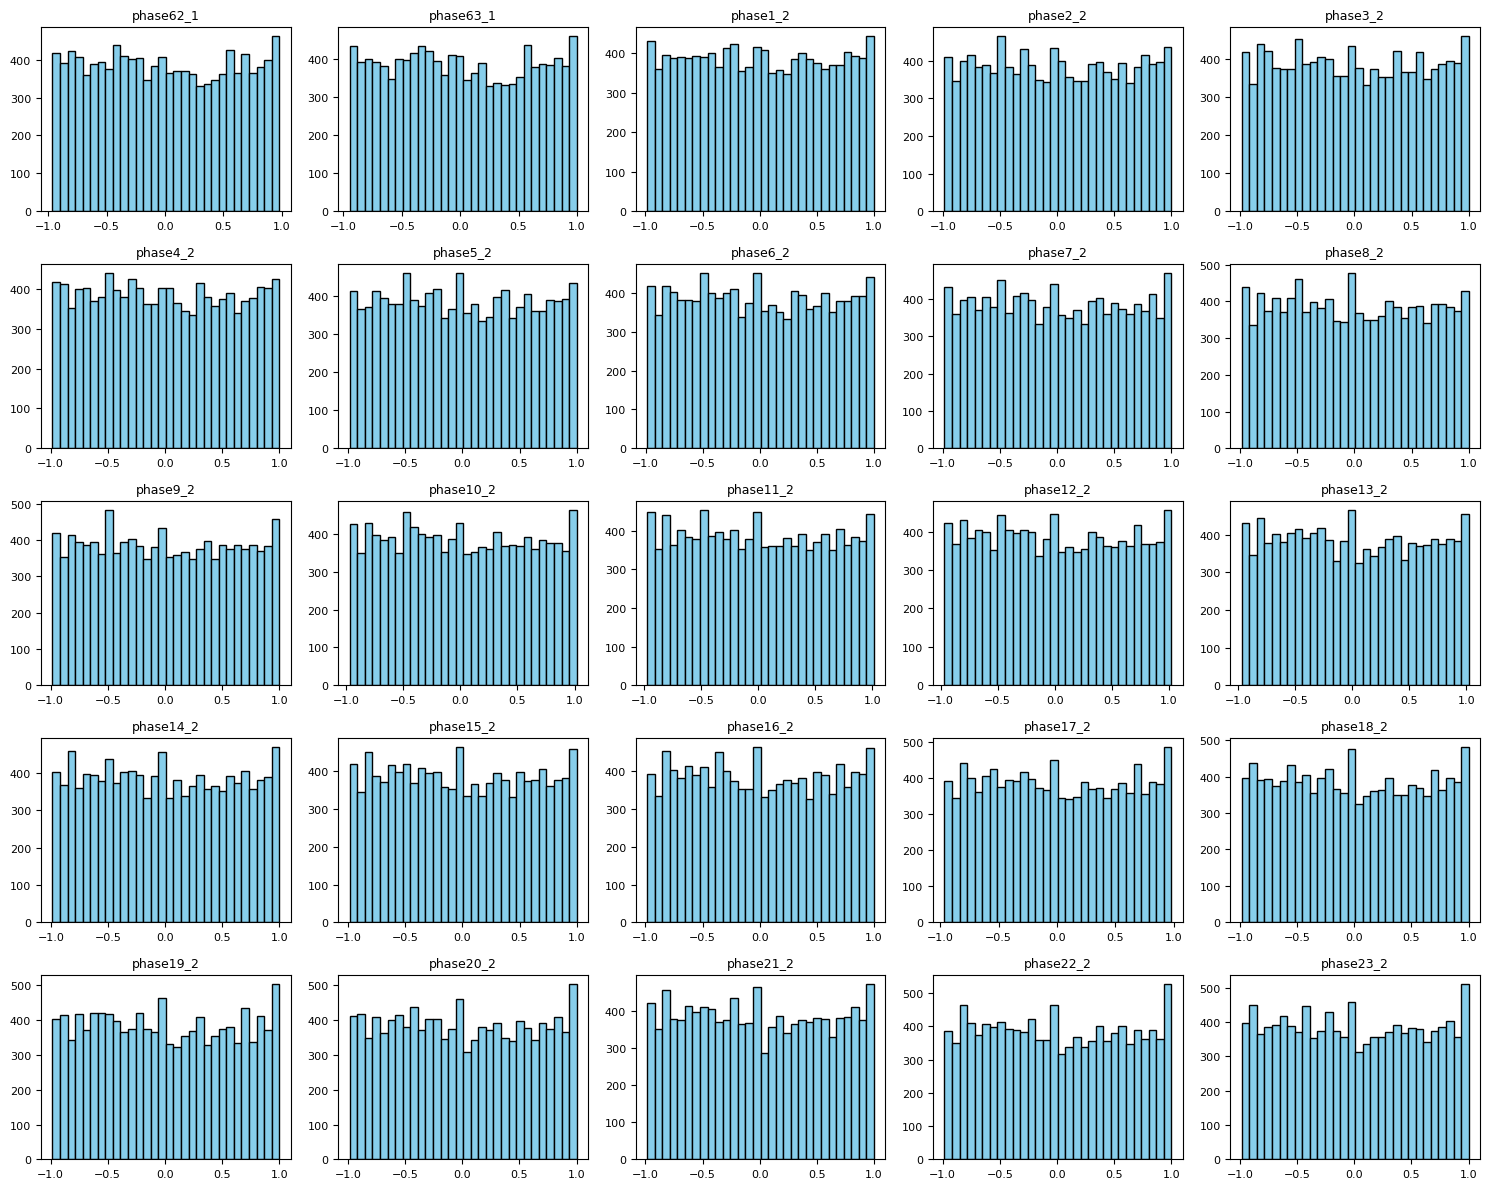

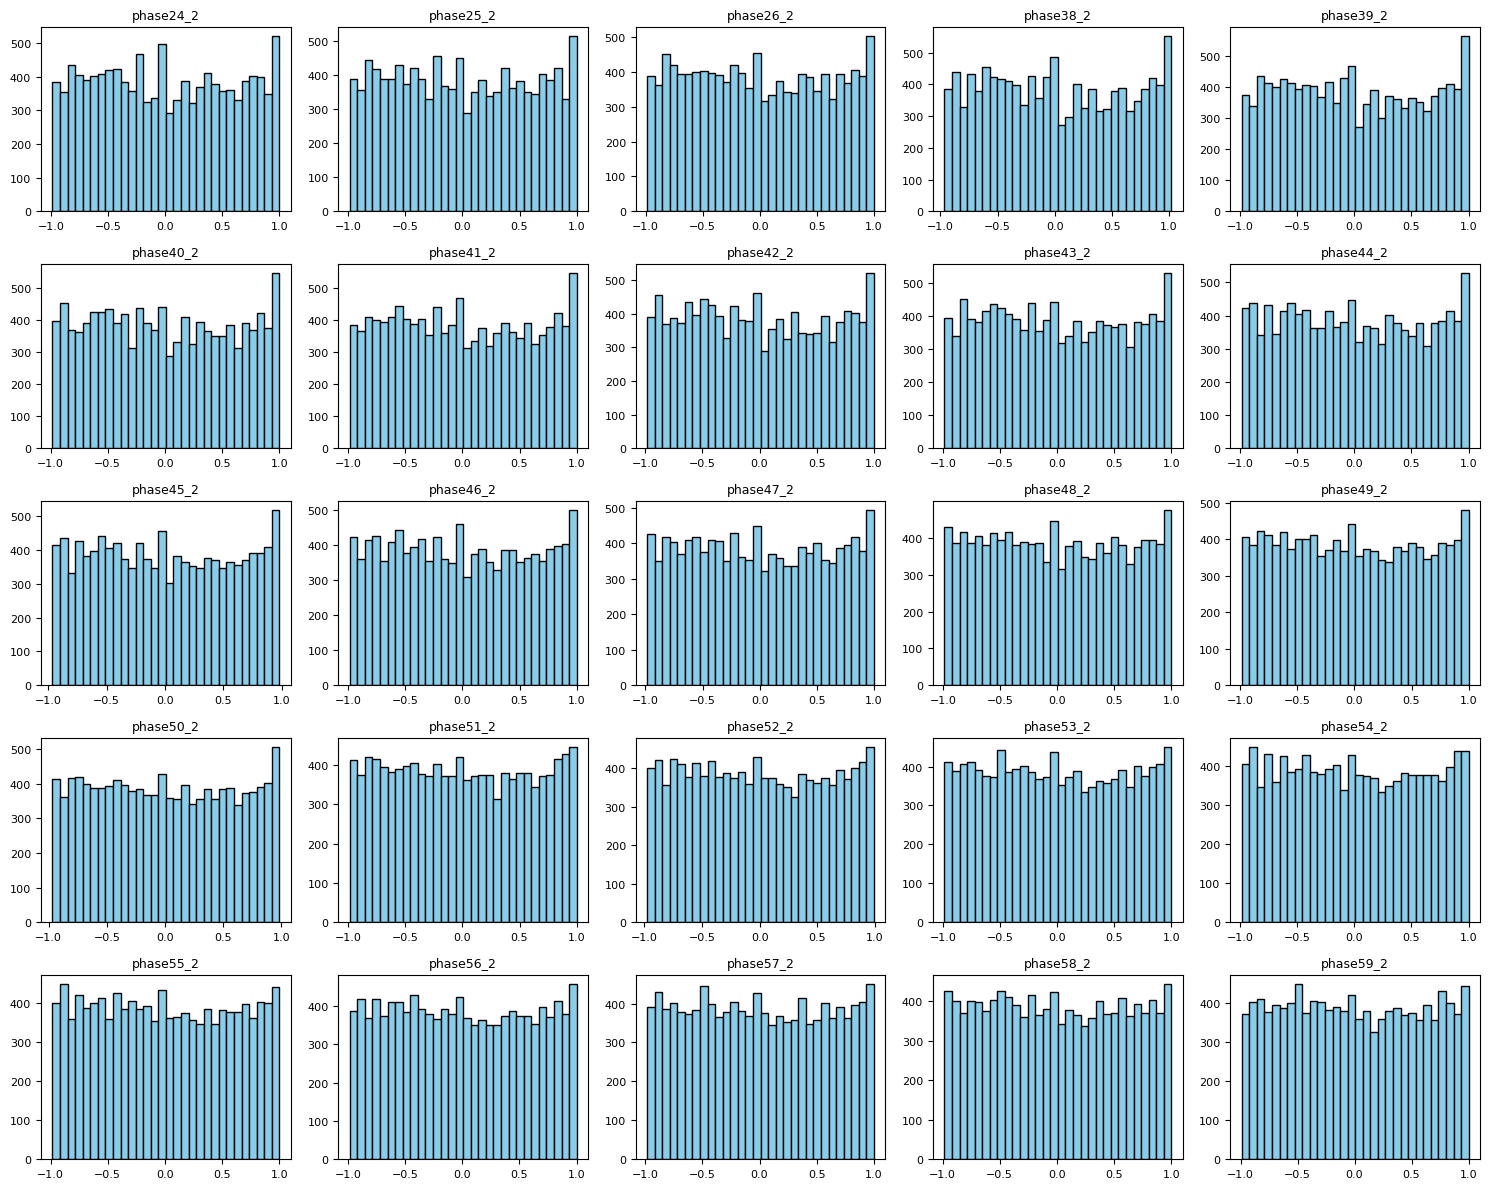

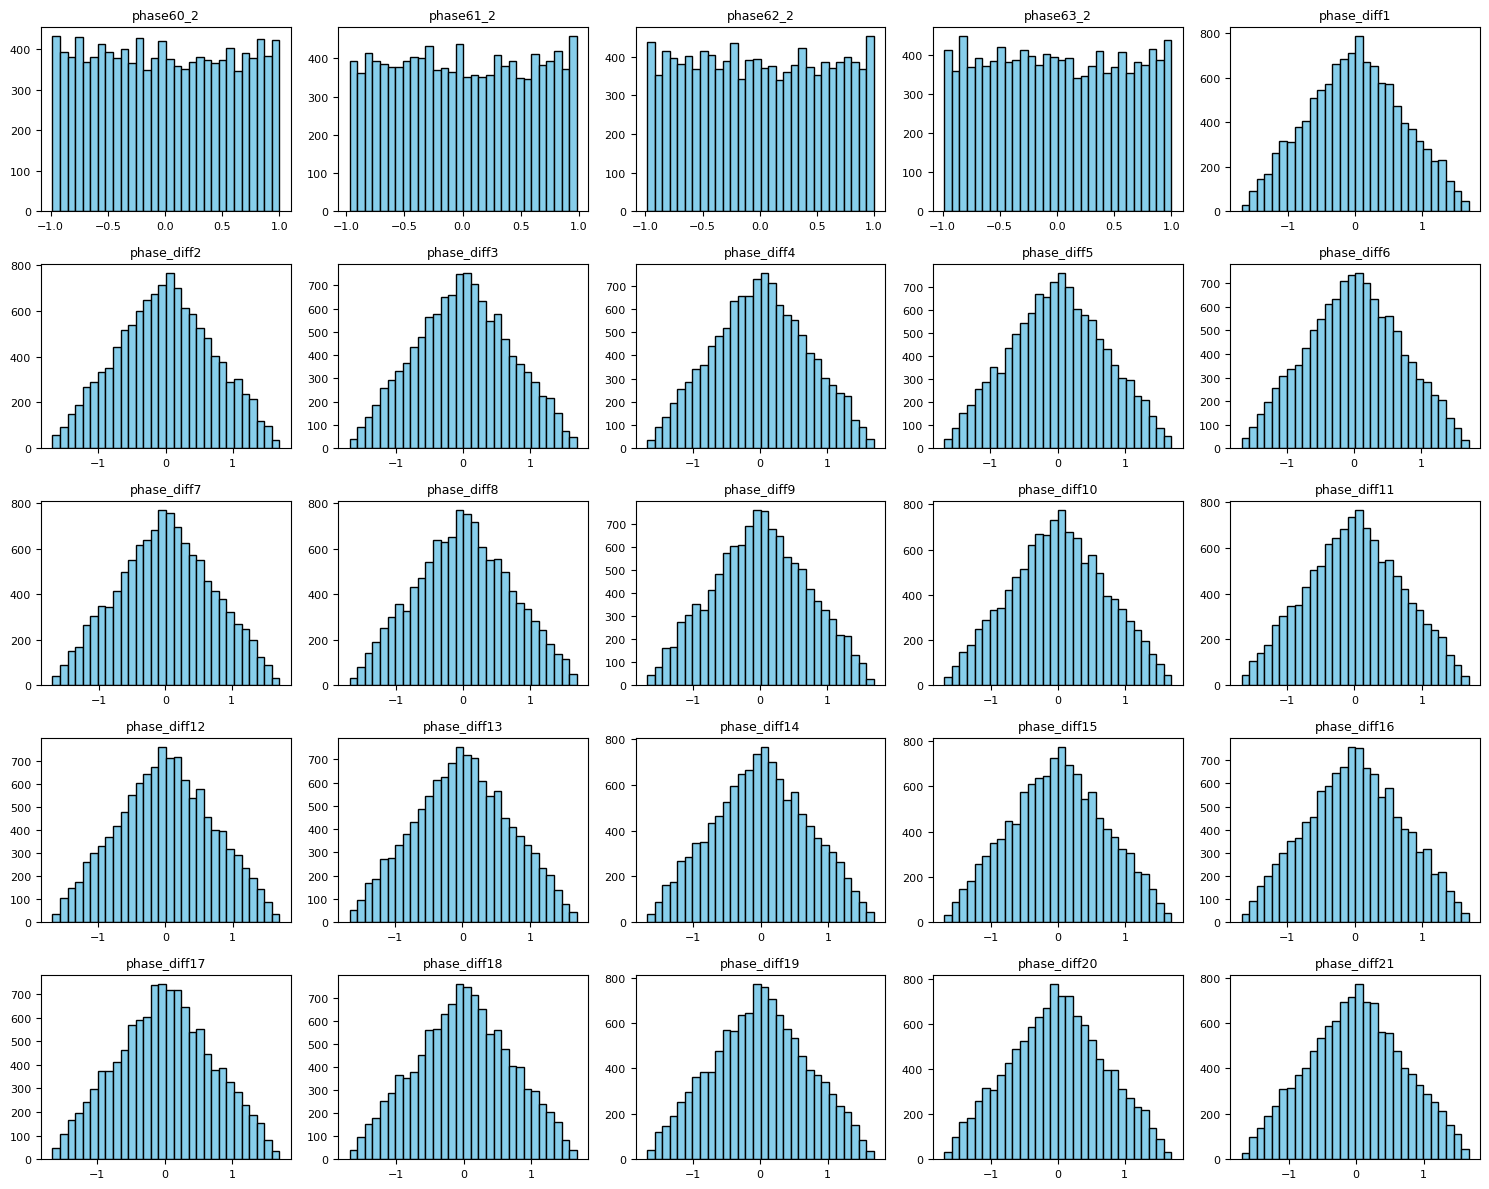

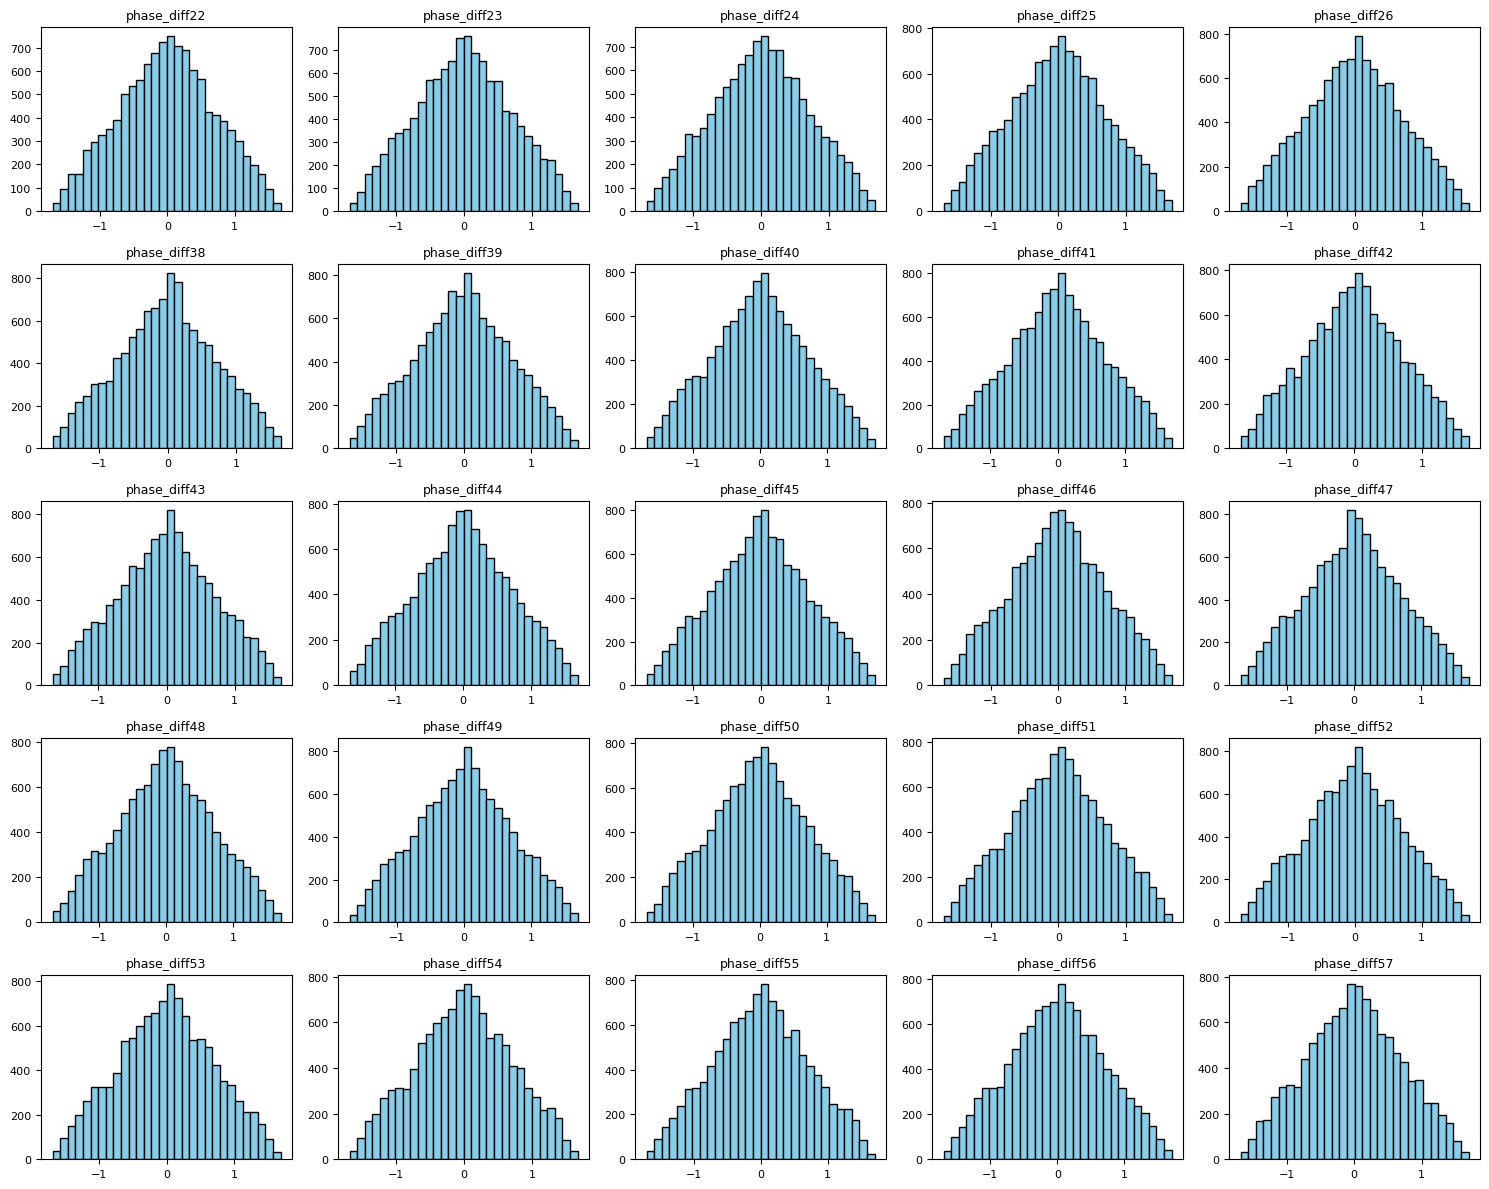

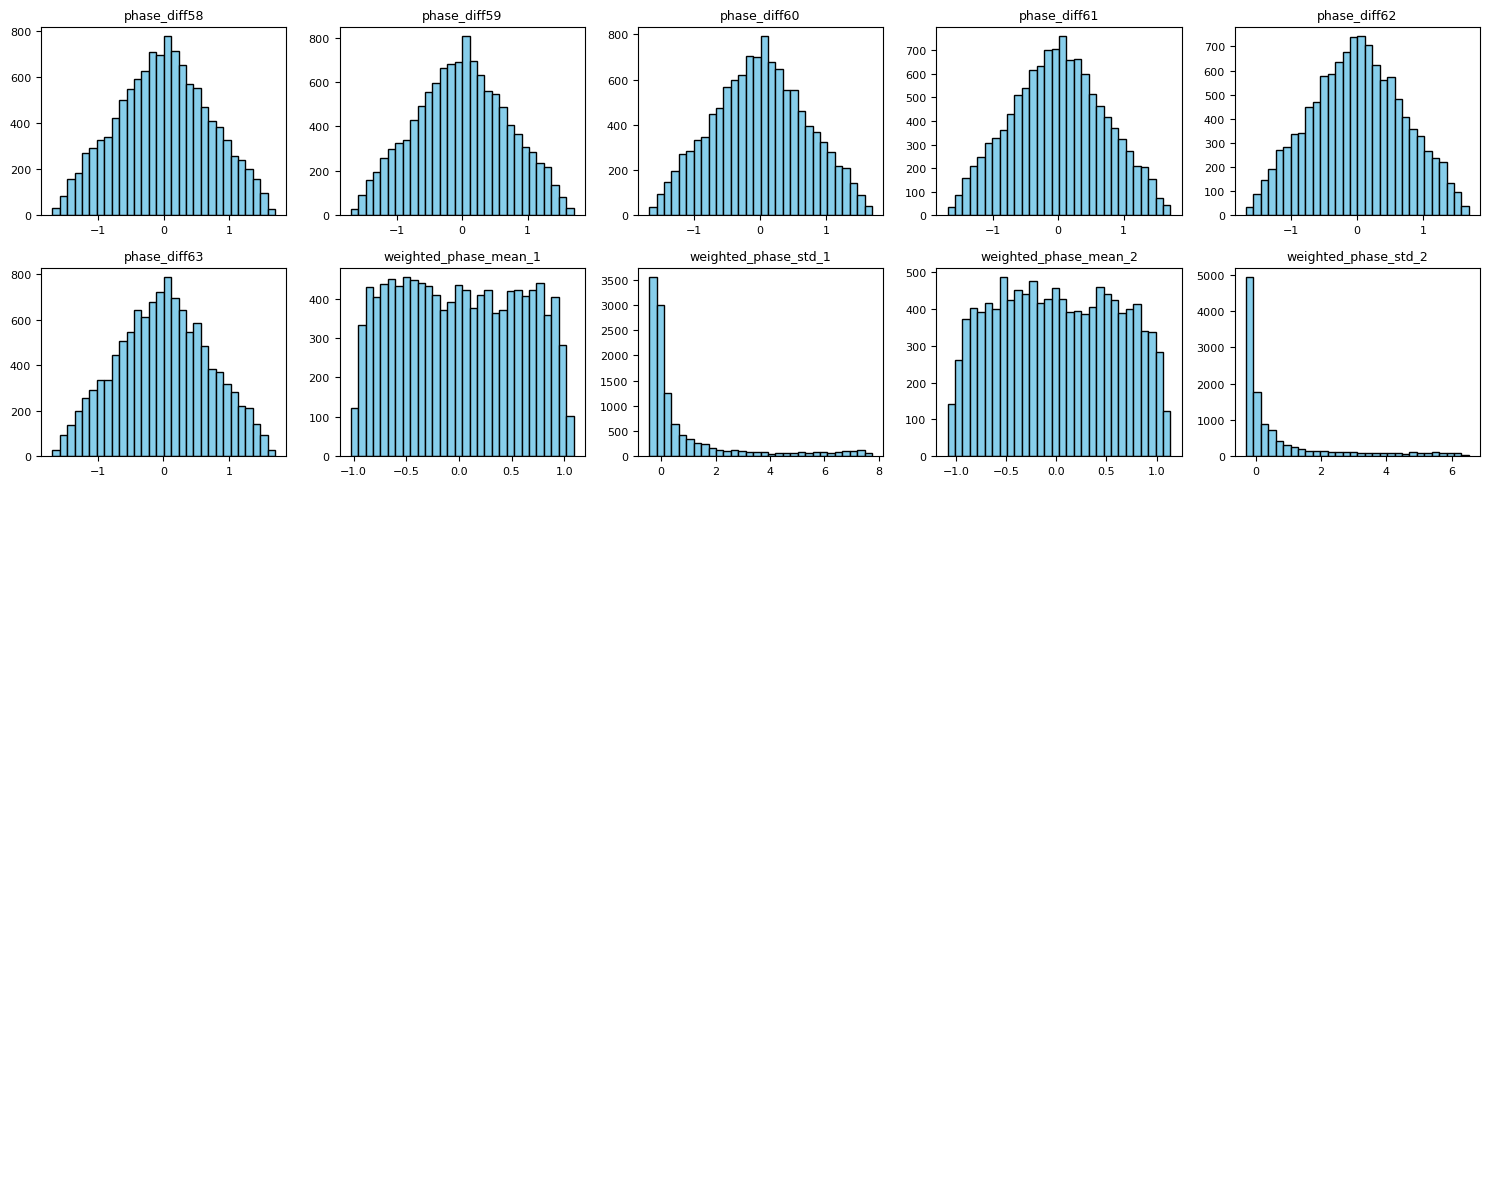

In [22]:
import matplotlib.pyplot as plt
import math

# 1. Identificar todas las columnas de fase (asumiendo que las llamaste 'phase...')
cols_phase = [col for col in wifi.columns if 'phase' in col]

# 2. Configuración de la cuadrícula
n_cols_grid = 5
n_rows_grid = 5
fotos_por_pagina = n_cols_grid * n_rows_grid

# 3. Bucle para mostrar de 25 en 25
for i in range(0, len(cols_phase), fotos_por_pagina):
    # Seleccionamos el bloque de 25 columnas
    bloque = cols_phase[i : i + fotos_por_pagina]
    
    # Creamos la figura
    fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(15, 12))
    axes = axes.flatten() # Aplanar para iterar fácilmente
    
    for j, col in enumerate(bloque):
        # Dibujar histograma en el subgráfico correspondiente
        axes[j].hist(wifi[col], bins=30, color='skyblue', edgecolor='black')
        axes[j].set_title(col, fontsize=9)
        axes[j].tick_params(labelsize=8)
    
    # Ocultar ejes vacíos si el último bloque tiene menos de 25
    for k in range(len(bloque), fotos_por_pagina):
        axes[k].axis('off')
    
    plt.tight_layout()
    plt.show()